In [1]:
# importer les librairies

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore") 


In [2]:
# charger les 2 datasets
df_raw = pd.read_csv("../data/raw/healthcare-dataset-stroke-data.csv")
df_processed = pd.read_csv("../data/processed/healthcare_stroke_dataset_clean.csv")

In [3]:
df_raw.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [4]:
df_processed.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,28.1,never smoked,1
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


### Nous allons faire une première exploration de notre dataset raw

In [5]:
df_raw.shape

(5110, 12)

In [6]:
df_raw.columns

Index(['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='str')

In [7]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   str    
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   str    
 6   work_type          5110 non-null   str    
 7   Residence_type     5110 non-null   str    
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   str    
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), str(5)
memory usage: 479.2 KB


Nous observons des valeurs manquantes dans la variable bmi

In [8]:
# vérification des données manquantes
df_raw.isnull().sum()

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

In [9]:
df_raw.isnull().sum()/len(df_raw)*100

id                   0.000000
gender               0.000000
age                  0.000000
hypertension         0.000000
heart_disease        0.000000
ever_married         0.000000
work_type            0.000000
Residence_type       0.000000
avg_glucose_level    0.000000
bmi                  3.933464
smoking_status       0.000000
stroke               0.000000
dtype: float64

La variable "bmi" comporte 201 données manquantes, soit 3,93%.

In [10]:
# vérifions s'il y'a des doublons
df_raw.duplicated().sum()

np.int64(0)

In [11]:
# statistiques des variables numériques
df_raw.describe().round(2)

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.00,5110.00,5110.0,5110.00,5110.00,4909.00,5110.00
mean,36517.83,43.23,0.1,0.05,106.15,28.89,0.05
std,21161.72,22.61,0.3,0.23,45.28,7.85,0.22
min,67.00,0.08,0.0,0.00,55.12,10.30,0.00
25%,17741.25,25.00,0.0,0.00,77.24,23.50,0.00
50%,36932.00,45.00,0.0,0.00,91.88,28.10,0.00
75%,54682.00,61.00,0.0,0.00,114.09,33.10,0.00
max,72940.00,82.00,1.0,1.00,271.74,97.60,1.00


In [12]:
# statistique des variables catégorielles
df_raw.describe(include=object)

,gender,ever_married,work_type,Residence_type,smoking_status
count,5110,5110,5110,5110,5110
unique,3,2,5,2,4
top,Female,Yes,Private,Urban,never smoked
freq,2994,3353,2925,2596,1892


Comme notre objectif est la prédiction d'un AVC, notre variable cible ici est "stroke"

In [13]:
# Pour chaque variable de type objet, nous allons observer les catégories de chaque variable
for col in df_raw.select_dtypes(include="object"):
    print("\n", col )
    print(df_raw[col].value_counts())


 gender
gender
Female    2994
Male      2115
Other        1
Name: count, dtype: int64

 ever_married
ever_married
Yes    3353
No     1757
Name: count, dtype: int64

 work_type
work_type
Private          2925
Self-employed     819
children          687
Govt_job          657
Never_worked       22
Name: count, dtype: int64

 Residence_type
Residence_type
Urban    2596
Rural    2514
Name: count, dtype: int64

 smoking_status
smoking_status
never smoked       1892
Unknown            1544
formerly smoked     885
smokes              789
Name: count, dtype: int64


### Analyse de la variable cible

In [14]:
# concernant la variable cible
df_raw["stroke"].value_counts()

stroke
0    4861
1     249
Name: count, dtype: int64

Cela nous montrele nombre de personnes qui :
ont eu un AVC (1) : 249
n'ont pas eu d'AVC (0): 4861

In [15]:
# ce qui représente en pourcentage:
(df_raw["stroke"].value_counts(normalize=True)*100).round(2)

stroke
0    95.13
1     4.87
Name: proportion, dtype: float64

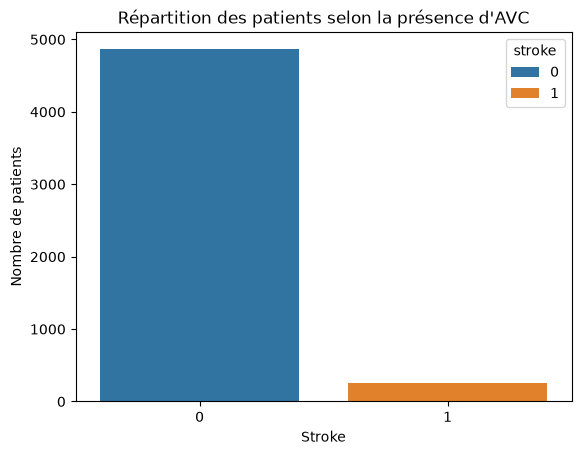

In [16]:
plt.Figure(figsize=(6,4))
sns.countplot(
    data=df_raw,
    x= "stroke",
    hue="stroke"
)
plt.title("Répartition des patients selon la présence d'AVC")
plt.xlabel("Stroke")
plt.ylabel("Nombre de patients")

plt.show()

La variable cible est fortement déséquilibrée. Les patients sans AVC représentent environ 95 % des observations contre seulement 5 % pour les patients ayant subi un AVC. Ce déséquilibre devra être pris en compte lors de l'entraînement des modèles afin d'éviter qu'ils privilégient systématiquement la classe majoritaire.

### Nous allons identifier nos variables afin de définir ce que nous en ferons:

In [17]:
variables = pd.DataFrame({"Variables": df_raw.columns,
              "Types": df_raw.dtypes.values})

variables

,Variables,Types
0,id,int64
1,gender,str
2,age,float64
3,hypertension,int64
4,heart_disease,int64
5,ever_married,str
6,work_type,str
7,Residence_type,str
8,avg_glucose_level,float64
9,bmi,float64


 Variable          | Type             | Prétraitement ML 
 ----------------- | ---------------- | ---------------- 
 age               | Numérique        | Standardisation  
 avg_glucose_level | Numérique        | Standardisation  
 bmi               | Numérique        | Standardisation  
 gender            | Catégorielle     | Encodage         
 ever_married      | Binaire (Yes/No) | Encodage         
 work_type         | Catégorielle     | Encodage         
 Residence_type    | Binaire          | Encodage         
 smoking_status    | Catégorielle     | Encodage         
 hypertension      | Binaire (0/1)    | Aucun            
 heart_disease     | Binaire (0/1)    | Aucun            
 stroke            | Variable cible   | —                


Ce tableau me sera utile dans le notebook 02_preprocessing, Car elle me permet de savoir

quelles colonnes encoder, 
lesquelles standardiser,
lesquelles laisser telles quelles.

### Nous allons vérifier les corrélations entre les variables pour comprendre les relations entre les variables numériques.

In [18]:
df_numeric = df_raw.select_dtypes(include="number")

corr_num = df_numeric.corr()
corr_num

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
id,1.000000,0.003538,0.003550,-0.001296,0.001092,0.003084,0.006388
age,0.003538,1.000000,0.276398,0.263796,0.238171,0.333398,0.245257
hypertension,0.003550,0.276398,1.000000,0.108306,0.174474,0.167811,0.127904
heart_disease,-0.001296,0.263796,0.108306,1.000000,0.161857,0.041357,0.134914
avg_glucose_level,0.001092,0.238171,0.174474,0.161857,1.000000,0.175502,0.131945
bmi,0.003084,0.333398,0.167811,0.041357,0.175502,1.000000,0.042374
stroke,0.006388,0.245257,0.127904,0.134914,0.131945,0.042374,1.000000


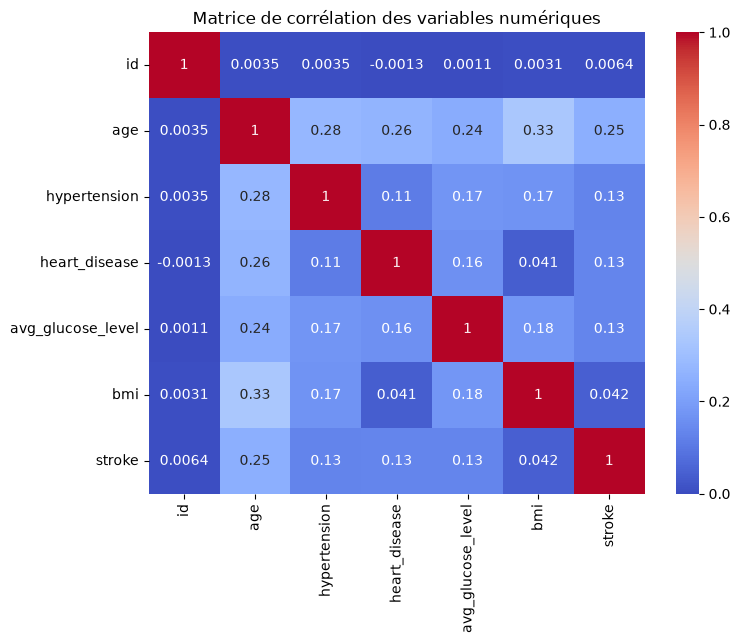

In [19]:
# nous allons observer cela grâce à un heatmap
plt.figure(figsize=(8,6))

sns.heatmap(
    corr_num,
    annot=True,
    cmap="coolwarm"
)

plt.title("Matrice de corrélation des variables numériques")

plt.show()

### Nous allons comprendre la distribution des variables et détecter les valeurs qui pourraient influencer les modèles de Machine Learning.

#### Analyse de la distribution des variables numériques

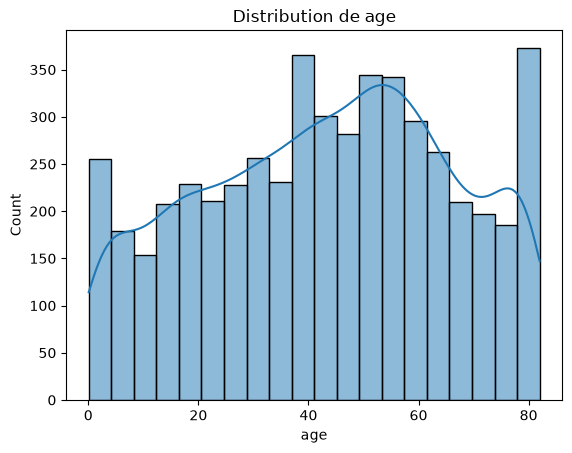

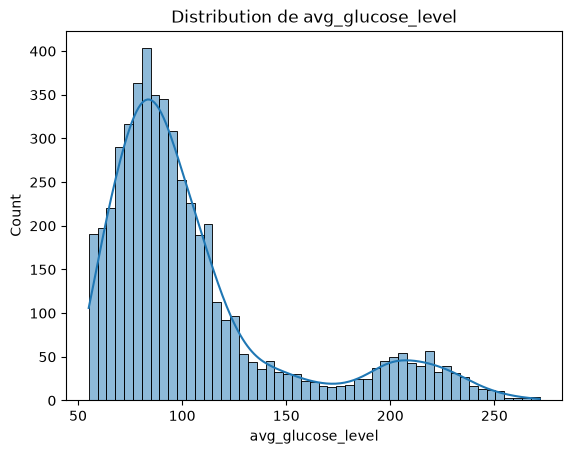

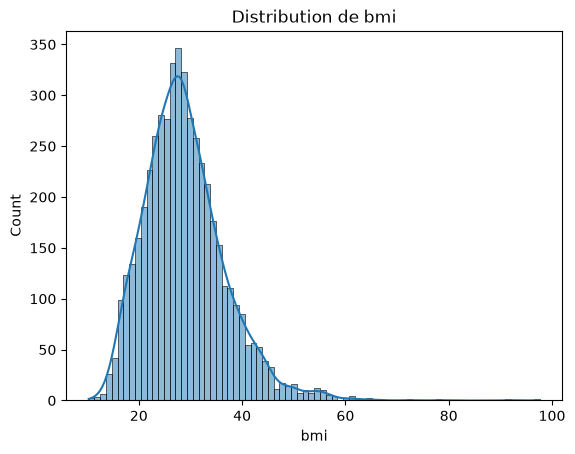

In [23]:
numeric_col = ["age", "avg_glucose_level", "bmi"]
for col in numeric_col:
    plt.Figure(figsize=(6,4))
    sns.histplot(
        data=df_raw,
        x=col,
        kde=True
    )
    plt.title(f"Distribution de {col}")

    plt.show()

### Détection des valeurs aberrantes

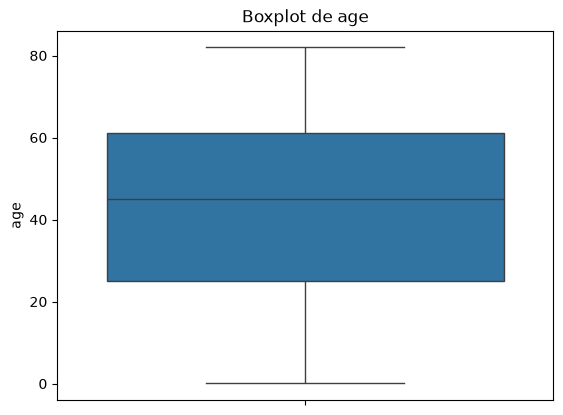

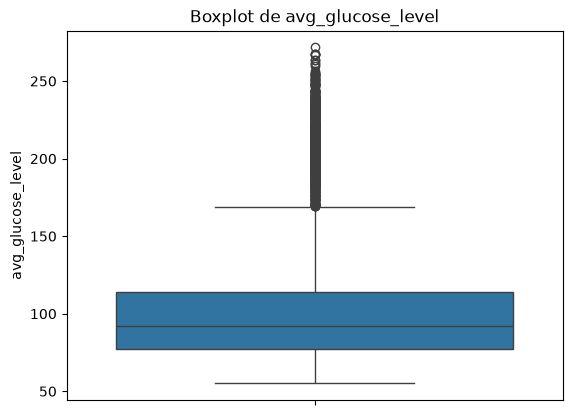

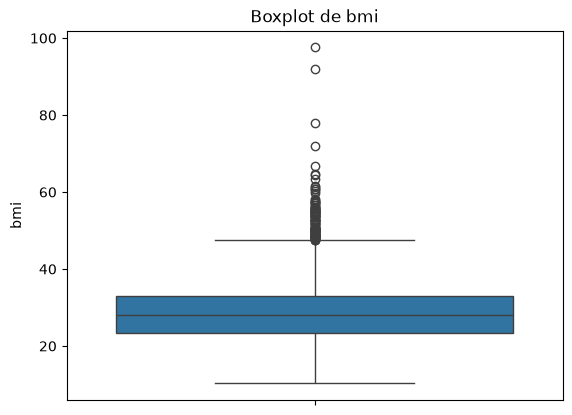

In [27]:
for col in numeric_col:
    plt.Figure(figsize=(5,3))
    sns.boxplot(data=df_raw[col])
    plt.title(f"Boxplot de {col}")

    plt.show()

#### Interprétations de nos variables numériques

##### age

La distribution de l'âge est asymétrique et présente plusieurs pics, traduisant une répartition hétérogène des patients selon les classes d'âge. 
Le boxplot ne met pas en évidence de valeurs aberrantes significatives, ce qui indique que les âges observés restent cohérents avec la population étudiée.

Ce qui traduit:
aucune valeur à supprimer,
notre variable `age`sera standardisée avant l'entraînement de certains modèles.

##### avg_glucode_level (Glycémie moyenne)

La distribution de la glycémie moyenne est fortement asymétrique, avec une majorité de patients présentant des valeurs relativement faibles et quelques patients présentant des valeurs beaucoup plus élevées. 
Le boxplot met en évidence plusieurs valeurs extrêmes au-delà d'environ 175 mg/dL.

Ce qui traduit:

Les valeurs élevées observer peuvent correspondre à des situations médicales réelles (patients diabétiques ou hyperglycémiques). 
Elles ne seront donc pas supprimées, mais la variable sera standardisée afin de limiter leur influence sur les modèles sensibles aux différences d'échelle.

##### bmi (IMC)

La distribution de l'IMC est également asymétrique et présente plusieurs valeurs élevées. 
Le boxplot identifie des valeurs extrêmes au-delà d'environ 43 kg/m².

Ce qui traduit:

Les observations sont plausibles dans un contexte médical (obésité sévère). 
Elles seront conservées dans le jeu de données et la variable sera standardisée avant l'entraînement.


#### Pour Conclure, nous pourrons dire que:

Nos variables numériques présentent des distributions asymétriques ainsi que plusieurs valeurs extrêmes. Toutefois, ces observations restent cohérentes dans un contexte médical et ne semblent pas résulter d'erreurs de saisie. 
De ce fait, Les valeurs seront donc conservées et les variables numériques seront standardisées lors de la phase de prétraitement.


### Analyse des variables catégorielles

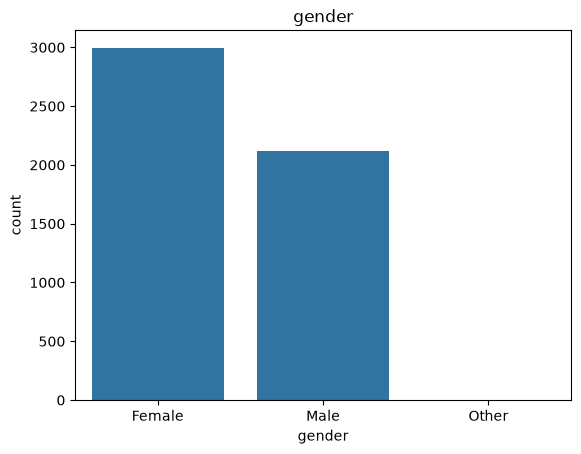

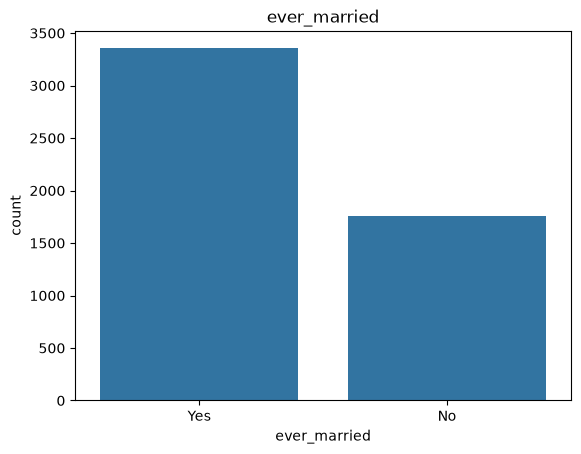

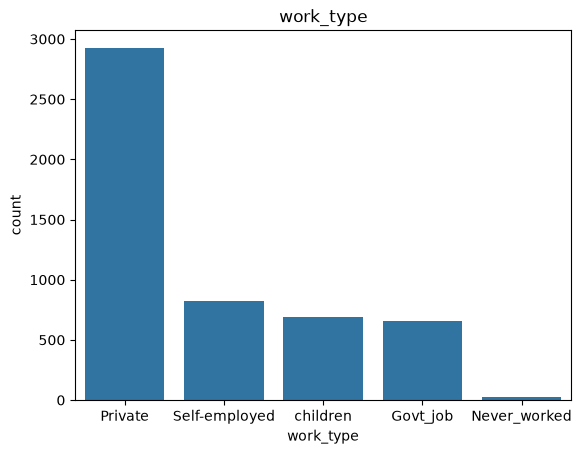

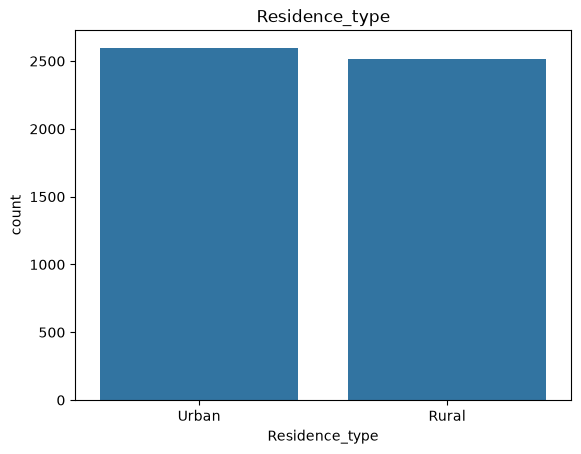

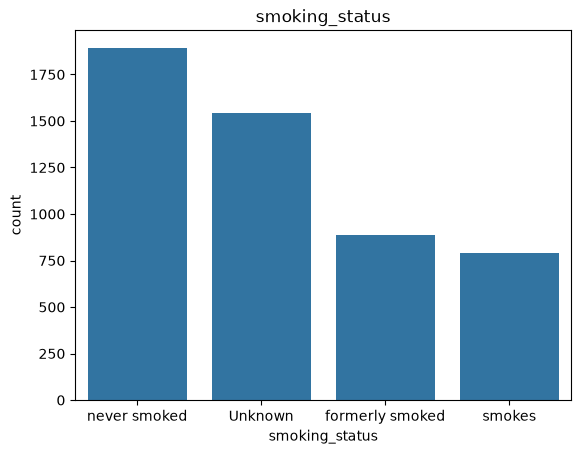

In [ ]:
categ_col = df_raw.select_dtypes(include="object")

for col in categ_col:
    plt.Figure(figsize=(6,4))
    sns.countplot(data=df_raw, 
                  x=col, 
                  order=df_raw[col].value_counts().index)
    

    plt.title(col)

    plt.show()


#### Interpretations

##### Gender (Genre)

La majorité des patients sont de sexe féminin, suivis des patients de sexe masculin. La catégorie Other est très peu représentée, ce qui pourrait poser des difficultés lors de l'entraînement des modèles.

Nous reviendrons sur cette catégorie un peu plus en aval.

##### ever_married (Situation matrimoniale)

La majorité des patients sont mariés. Les deux catégories sont néanmoins suffisamment représentées pour être utilisées lors de la modélisation.

##### work_type (Type d'emploi)

La catégorie Private représente la majorité des observations. A l'inverse, la catégorie Never_worked est extrêmement rare, avec seulement une dizaine d'observations.

Nous verrons lors du prétraitement si nous devons ou non conserver cette catégorie never_worked.

##### residence_type (Lie de résidence)

Les catégories Urban et Rural sont presque parfaitement équilibrées. Aucun déséquilibre particulier n'est observé.

##### smoking_status (Tabagisme)

La catégorie Never smoked est la plus fréquente, suivie de Unknown. Les catégories Formerly smoked et Smokes restent suffisamment représentées pour être conservées.

Le fait que Unknown soit assez fréquent mérite une attention particulière. 
Vue que la catégorie Unknown ne décrit pas explicitement quel type cela est, nous déciderons plus tard si nous la conservons comme une modalité à part entière ou si une autre stratégie est plus pertinente.

### Nous allons comparer notre dataset raw avec notre dataset clean processed

In [20]:
print (f" df_raws comportent les colonnes : {df_raw.columns}")

print ("########################################################")
print ("########################################################")
print ("########################################################")

print (f" df_processed comportent les colonnes : {df_processed.columns}")

 df_raws comportent les colonnes : Index(['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='str')
########################################################
########################################################
########################################################
 df_processed comportent les colonnes : Index(['gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='str')


on observe que la conne "id" a été supprimé dans df_processed